In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

load_dotenv('../ingestion/.env')  # reuse .env to prevent leak
os.getcwd()

'c:\\Users\\Alvin\\Music\\project_1\\notebook'

### A. Explaratory Data Analysis

In [236]:
# Koneksi ke Postgres, baca langsung dari tabel marts hasil dbt
DB_USER = os.getenv("DB_USER", "alvin")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "price_intelligence")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

#Schema: 'public' fact table from mart
df_raw = pd.read_sql("SELECT * FROM public.fct_ebay_listings", engine)

print(f"Total baris: {len(df_raw)}")
df_raw.head()

Total baris: 1794


,item_id,title,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,total_risk_score,risk_category,volume_confidence
0,v1|115965603147|0,Spy Classroom Volumes 1-3 Light Novel Set New ...,USD,Brand New,US,True,False,False,False,40.50,13.5000,1.0,3.0,0,Low Risk,medium
1,v1|116263745717|0,"Gimai Seikatsu, Days with My Step Sister Light...",USD,Brand New,MY,True,False,False,False,149.90,18.7375,1.0,8.0,70,High Risk,medium
2,v1|116268231670|0,"Bofuri: I Don't Want to Get Hurt, so I'll Max ...",USD,Brand New,US,False,False,False,False,17.20,17.2000,13.0,NaN,0,Low Risk,medium
3,v1|117165076117|0,"Overlord, Vol. 6 (light Novel) : The Men of th...",USD,Brand New,US,False,False,False,False,16.49,16.4900,6.0,NaN,0,Low Risk,high
4,v1|117177109407|0,Mushoku Tensei: Jobless Reincarnation (Light N...,USD,Brand New,US,False,False,False,False,14.85,14.8500,5.0,NaN,0,Low Risk,medium


#### A.1 Data Inspection

In [237]:
df_raw.describe()

,price,price_per_volume,volume_number,volume_number_end,total_risk_score
count,1794.000000,1794.000000,1525.000000,511.000000,1794.000000
mean,69.595061,27.408821,4.471475,14.720157,14.788183
std,97.953154,55.075453,5.110781,8.452750,27.687096
min,2.490000,0.302093,0.000000,2.000000,0.000000
25%,13.320000,10.727019,1.000000,8.750000,0.000000
50%,21.015000,14.603846,2.000000,13.000000,0.000000
75%,103.060000,21.232500,6.000000,19.000000,15.000000
max,1099.990000,1000.000000,29.000000,45.000000,100.000000


In [238]:
missing_summary = df_raw.isnull().sum().to_frame('missing_count')
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(df_raw) * 100).round(1)
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_%
volume_number_end,1283,71.5
volume_number,269,15.0
condition,18,1.0
item_id,0,0.0
seller_location,0,0.0
is_boxset,0,0.0
title,0,0.0
currency,0,0.0
boxset_side_story_edition_included,0,0.0
is_special_edition,0,0.0


In [239]:
print(f"risk_category distribution (all):{df_raw['risk_category'].value_counts()}")

df_price_model = df_raw[(df_raw['risk_category'] != 'High Risk') & (df_raw['volume_confidence'] != 'low')]
print(f"risk_category distribution (w/0 high risk & > low confidence): {df_price_model['risk_category'].value_counts()}")

risk_category distribution (all):risk_category
Low Risk     1478
High Risk     316
Name: count, dtype: int64
risk_category distribution (w/0 high risk & > low confidence): risk_category
Low Risk    1202
Name: count, dtype: int64


In [276]:
df_raw[df_raw['is_special_edition'] == True].describe()

,price,price_per_volume,volume_number,volume_number_end,total_risk_score
count,65.000000,65.000000,40.000000,2.000000,65.000000
mean,122.294923,111.182097,5.362500,21.500000,3.692308
std,147.502170,138.237446,4.982003,6.363961,14.928918
min,8.850000,8.850000,1.000000,17.000000,0.000000
25%,54.000000,48.790000,1.000000,19.250000,0.000000
50%,69.990000,68.990000,4.000000,21.500000,0.000000
75%,187.530000,187.530000,8.000000,23.750000,0.000000
max,999.000000,999.000000,17.000000,26.000000,70.000000


#### A.2 Data Figure

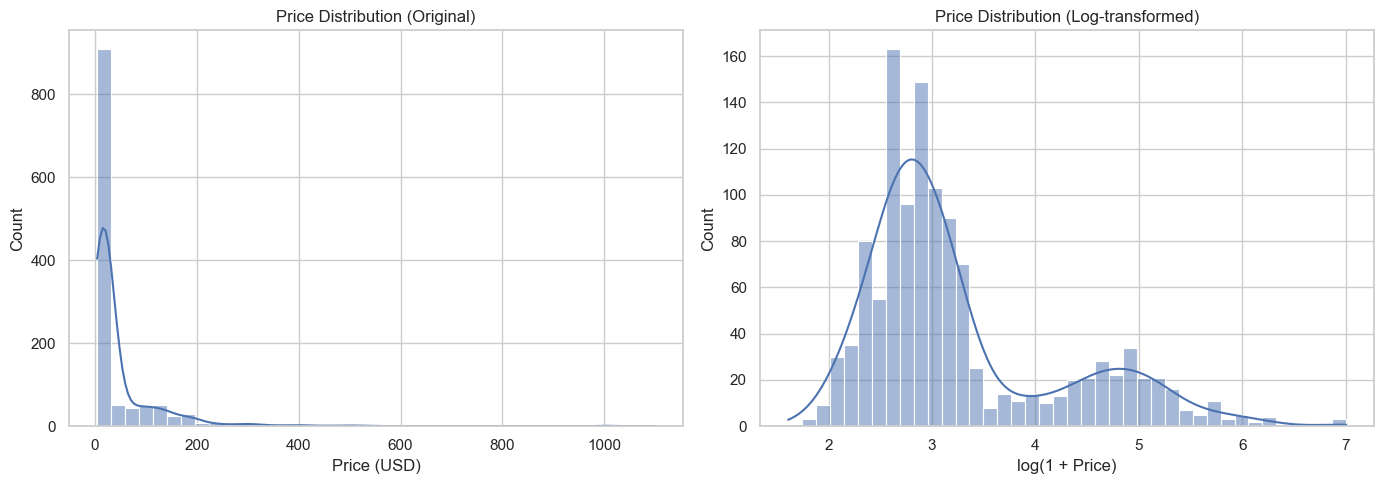

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model['price'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model['price']), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

In [241]:
print(df_price_model['price'].describe())

print(np.log1p(df_price_model['price']).describe())

count    1202.000000
mean       47.550524
std        84.645049
min         4.000000
25%        12.990000
50%        17.990000
75%        30.000000
max      1099.990000
Name: price, dtype: float64
count    1202.000000
mean        3.259439
std         0.955443
min         1.609438
25%         2.638343
50%         2.943913
75%         3.433987
max         7.003965
Name: price, dtype: float64


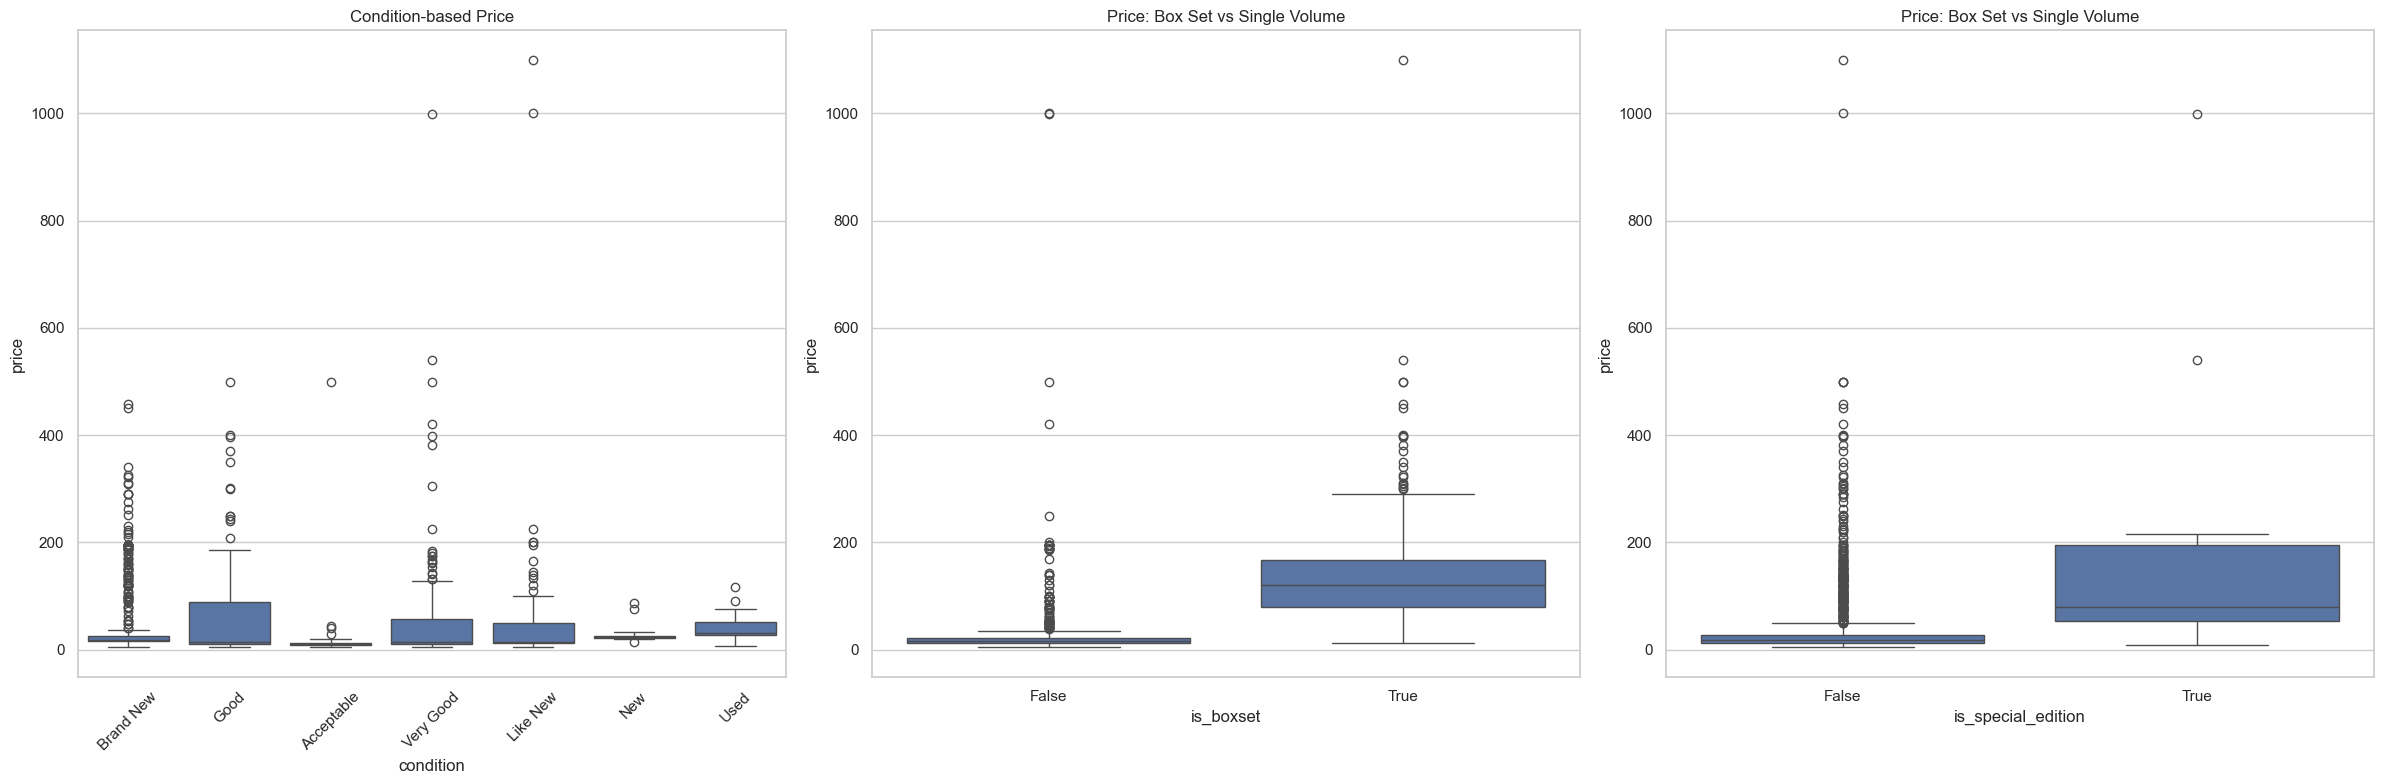

In [242]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

sns.boxplot(data=df_price_model, x='condition', y='price', ax=axes[0])
axes[0].set_title('Condition-based Price')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_price_model, x='is_boxset', y='price', ax=axes[1])
axes[1].set_title('Price: Box Set vs Single Volume')

sns.boxplot(data=df_price_model, x='is_special_edition', y='price', ax=axes[2])
axes[2].set_title('Price: Box Set vs Single Volume')

plt.tight_layout()
plt.show()

In [243]:
df_price_model[df_price_model['price'] > 250].head(5)

,item_id,title,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,total_risk_score,risk_category,volume_confidence
18,v1|125075935916|429071507693,Re:Zero: Starting Life in Another World Vol.1-...,USD,Brand New,JP,True,False,False,False,458.88,10.429091,1.0,44.0,0,Low Risk,high
43,v1|127898400680|0,Classroom of the Elite Light Novel Complete Se...,USD,Brand New,US,True,False,True,False,449.99,40.908182,1.0,11.0,0,Low Risk,medium
52,v1|127963081280|0,Re:Zero Starting Life in Another World Vol.1-4...,USD,Good,JP,True,False,False,False,370.00,8.409091,1.0,44.0,0,Low Risk,high
114,v1|147237499460|0,Mushoku Tensei Jobless Reincarnation Light Nov...,USD,Very Good,JP,True,False,False,False,398.78,15.337692,1.0,26.0,0,Low Risk,medium
154,v1|154976745230|0,Mushoku Tensei Volume 1- 26 complete Light Nov...,USD,Good,JP,True,False,False,False,399.99,15.384231,1.0,26.0,0,Low Risk,medium


In [244]:
for col in ['condition', 'seller_location']:
    print(f"{col}: {df_price_model[col].nunique()} kategori unik")
    print(df_price_model[col].value_counts())
    print()

condition: 7 kategori unik
condition
Brand New     554
Good          251
Very Good     175
Like New      111
New            54
Acceptable     34
Used           17
Name: count, dtype: int64

seller_location: 7 kategori unik
seller_location
US    928
JP    165
MY     41
GB     33
AU     31
CA      3
DE      1
Name: count, dtype: int64



### B.1 Modelling & Building Pipeline

In [245]:
import numpy as np

def calculate_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    # Avoid division by zero when both y_true and y_pred are 0
    epsilon = 1e-10
    denominator = np.where(denominator == 0, epsilon, denominator)
    
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

In [246]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler

numeric_features = df_price_model.select_dtypes(include=['int', 'float']).columns.tolist()
categorical_features = df_price_model.select_dtypes(exclude=['int', 'float']).columns.tolist()

feature_cols = numeric_features + categorical_features
target_col = 'price'

X = df_price_model[feature_cols].drop(columns = ['price', 'price_per_volume'])
y = df_price_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 961, Test: 241


In [247]:
X_train.head(5)

,volume_number,volume_number_end,total_risk_score,item_id,title,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,risk_category,volume_confidence
1020,26.0,NaN,0,v1|336711144903|0,"RE: Zero -Starting Life in Another World-, Vol...",USD,Brand New,US,False,False,False,False,Low Risk,high
364,1.0,16.0,0,v1|188135687635|0,Overlord Vol.1-16 Latest Full Set Japanese Ver...,USD,Very Good,JP,True,False,False,False,Low Risk,high
735,17.0,NaN,0,v1|278227410461|0,Konosuba: God's Blessing on This Wonderful Wor...,USD,Very Good,US,False,False,False,False,Low Risk,high
741,5.0,NaN,0,v1|278244748308|0,Classroom of the Elite: Year 2 (Light Novel) V...,USD,Like New,US,False,False,False,False,Low Risk,high
111,1.0,4.0,0,v1|146646284644|0,"Spy Classroom, Vols.1-4 (light Novel) by Take...",USD,Acceptable,US,True,False,False,False,Low Risk,medium


In [248]:
numeric_features = X.select_dtypes(include=['int', 'float']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['int', 'float']).columns.tolist()

X.isna().sum()

volume_number                           0
volume_number_end                     969
total_risk_score                        0
item_id                                 0
title                                   0
currency                                0
condition                               6
seller_location                         0
is_boxset                               0
is_special_edition                      0
boxset_side_story_edition_included      0
standalone_side_story_edition           0
risk_category                           0
volume_confidence                       0
dtype: int64

In [249]:
X_train['volume_number_end'] = X_train['volume_number_end'].fillna(0)
X_train['volume_count'] = X_train['volume_number_end'] - X_train['volume_number']

X_test['volume_number_end'] = X_test['volume_number_end'].fillna(0)
X_test['volume_count'] = X_test['volume_number_end'] - X_test['volume_number']
#----------------------------------------------------------------------------------
# X_train['aspect_unit_of_sale'] = X_train['aspect_unit_of_sale'].fillna(0)
# X_test['aspect_unit_of_sale'] = X_test['aspect_unit_of_sale'].fillna(0)
#----------------------------------------------------------------------------------
X_train['condition'] = X_train['condition'].fillna('unknown')
X_test['condition'] = X_test['condition'].fillna('unknown')


In [250]:
delta_volume = X_train['volume_number_end'] - X_train['volume_number']
X_train['volume_count'] = np.where(delta_volume < 0, 1, delta_volume + 1)

delta_volume = X_test['volume_number_end'] - X_test['volume_number']
X_test['volume_count'] = np.where(delta_volume < 0, 1, delta_volume + 1)


In [251]:
(X_train['volume_count'] < 0).sum()
display(X_train[X_train['volume_count'] < 0].head(5))

,volume_number,volume_number_end,total_risk_score,item_id,title,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,risk_category,volume_confidence,volume_count


In [252]:
X_train.head(5)

,volume_number,volume_number_end,total_risk_score,item_id,title,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,risk_category,volume_confidence,volume_count
1020,26.0,0.0,0,v1|336711144903|0,"RE: Zero -Starting Life in Another World-, Vol...",USD,Brand New,US,False,False,False,False,Low Risk,high,1.0
364,1.0,16.0,0,v1|188135687635|0,Overlord Vol.1-16 Latest Full Set Japanese Ver...,USD,Very Good,JP,True,False,False,False,Low Risk,high,16.0
735,17.0,0.0,0,v1|278227410461|0,Konosuba: God's Blessing on This Wonderful Wor...,USD,Very Good,US,False,False,False,False,Low Risk,high,1.0
741,5.0,0.0,0,v1|278244748308|0,Classroom of the Elite: Year 2 (Light Novel) V...,USD,Like New,US,False,False,False,False,Low Risk,high,1.0
111,1.0,4.0,0,v1|146646284644|0,"Spy Classroom, Vols.1-4 (light Novel) by Take...",USD,Acceptable,US,True,False,False,False,Low Risk,medium,4.0


In [253]:
X_train.isna().sum()

volume_number                         0
volume_number_end                     0
total_risk_score                      0
item_id                               0
title                                 0
currency                              0
condition                             0
seller_location                       0
is_boxset                             0
is_special_edition                    0
boxset_side_story_edition_included    0
standalone_side_story_edition         0
risk_category                         0
volume_confidence                     0
volume_count                          0
dtype: int64

In [254]:
X_test.isna().sum()

volume_number                         0
volume_number_end                     0
total_risk_score                      0
item_id                               0
title                                 0
currency                              0
condition                             0
seller_location                       0
is_boxset                             0
is_special_edition                    0
boxset_side_story_edition_included    0
standalone_side_story_edition         0
risk_category                         0
volume_confidence                     0
volume_count                          0
dtype: int64

In [255]:
df_price_model[df_price_model['price'] < 0]

,item_id,title,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,total_risk_score,risk_category,volume_confidence


In [256]:
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

In [257]:
X_train

,volume_number,volume_number_end,total_risk_score,item_id,title,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,risk_category,volume_confidence,volume_count
1020,26.0,0.0,0,v1|336711144903|0,"RE: Zero -Starting Life in Another World-, Vol...",USD,Brand New,US,False,False,False,False,Low Risk,high,1.0
364,1.0,16.0,0,v1|188135687635|0,Overlord Vol.1-16 Latest Full Set Japanese Ver...,USD,Very Good,JP,True,False,False,False,Low Risk,high,16.0
735,17.0,0.0,0,v1|278227410461|0,Konosuba: God's Blessing on This Wonderful Wor...,USD,Very Good,US,False,False,False,False,Low Risk,high,1.0
741,5.0,0.0,0,v1|278244748308|0,Classroom of the Elite: Year 2 (Light Novel) V...,USD,Like New,US,False,False,False,False,Low Risk,high,1.0
111,1.0,4.0,0,v1|146646284644|0,"Spy Classroom, Vols.1-4 (light Novel) by Take...",USD,Acceptable,US,True,False,False,False,Low Risk,medium,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,1.0,0.0,0,v1|398209618002|0,Ascendance of a Bookworm: Part 1 Volume 2 (Lig...,USD,Brand New,GB,False,False,False,False,Low Risk,medium,1.0
1604,4.0,0.0,0,v1|404682290499|0,"Bofuri: I Don't Want to Get Hurt, So I'll Max ...",USD,Good,US,False,False,False,False,Low Risk,medium,1.0
1651,17.0,0.0,0,v1|406934453872|0,"Bofuri: I Don't Want to Get Hurt, So I'll Max ...",USD,Brand New,US,False,False,False,False,Low Risk,medium,1.0
1268,4.0,0.0,15,v1|366540423197|0,Ascendance of a Bookworm: Part 4 Volume 5 (Lig...,USD,Very Good,US,False,False,False,False,Low Risk,medium,1.0


In [258]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('id_drop', 'drop', ['item_id', 'title'])
    ],
    remainder = 'passthrough'
)

def change_model(model_reggressor):
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       # Applied to 'y' automatically before fitting
        inverse_func=np.expm1 # Applied to predictions automatically
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', StandardScaler(with_mean=False)),
        ('regressor', model)
    ])

    baseline_pipeline.fit(X_train, y_train)
    y_pred = baseline_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"R^2     : {r2:.3f}")
    print(f"MAE     : {mae:.2f}")
    print(f"RMSE    : {rmse:.2f}")
    print(f"MAPE    : {mape:.3f}")
    print(f"SMAPE   : {smape:.3f}")

    results = pd.DataFrame({
        'item_id': X_test['item_id'],
        'title': X_test['title'],
        'volume_count': X_test['volume_count'],
        'Actual': y_test.values if hasattr(y_test, 'values') else y_test,
        'Predicted': y_pred
    }, index=X_test.index)

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    # Tampilkan 10 sampel dengan error terbesar
    display(results.sort_values(by='Abs_Error', ascending=False))

    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Actual vs Predicted
    axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
    axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Actual vs Predicted')

    # Plot 2: Residual Plot
    axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residual (Actual - Predicted)')
    axes[1].set_title('Residual Plot')

    plt.tight_layout()
    plt.show()

    return baseline_pipeline

#### B.1 Linear Regression

R^2     : 0.130
MAE     : 27.27
RMSE    : 101.86
MAPE    : 0.374
SMAPE   : 36.286


,item_id,title,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
838,v1|298576738093|0,Mushoku Tensei: Jobless Reincarnation (Light N...,1.0,1000.00,16.373844,983.626156,983.626156,98.362616
1401,v1|388779634089|0,BGS9.6 Rascal Does Not Dream of Bunny Girl Sen...,1.0,999.00,58.232383,940.767617,940.767617,94.170933
263,v1|168599137130|0,Classroom of the Elite Light Novel English Vol...,11.0,500.00,40.563343,459.436657,459.436657,91.887331
874,v1|307070837046|0,Classroom Of The Elite Year 2 Volume 1 2 3 4 4...,1.0,249.99,18.077528,231.912472,231.912472,92.768700
1059,v1|357703126460|0,Mushoku Tensei Jobless Reincarnation (Light No...,26.0,339.99,115.622135,224.367865,224.367865,65.992490
...,...,...,...,...,...,...,...,...
1783,v1|800463389714|0,Ascendance of a Bookworm: Part 4 Volume 9 (Lig...,1.0,19.89,20.251171,-0.361171,0.361171,1.815843
1324,v1|377183108473|0,Mushoku Tensei: Jobless Reincarnation Light No...,1.0,19.99,19.841164,0.148836,0.148836,0.744554
423,v1|198459568601|0,"The Eminence in Shadow, Vol. 4 (light novel) (...",1.0,15.55,15.649622,-0.099622,0.099622,0.640655
1746,v1|800284702346|0,"Overlord, Vol. 5 (Light Novel): The Men of the...",1.0,19.35,19.309075,0.040925,0.040925,0.211499


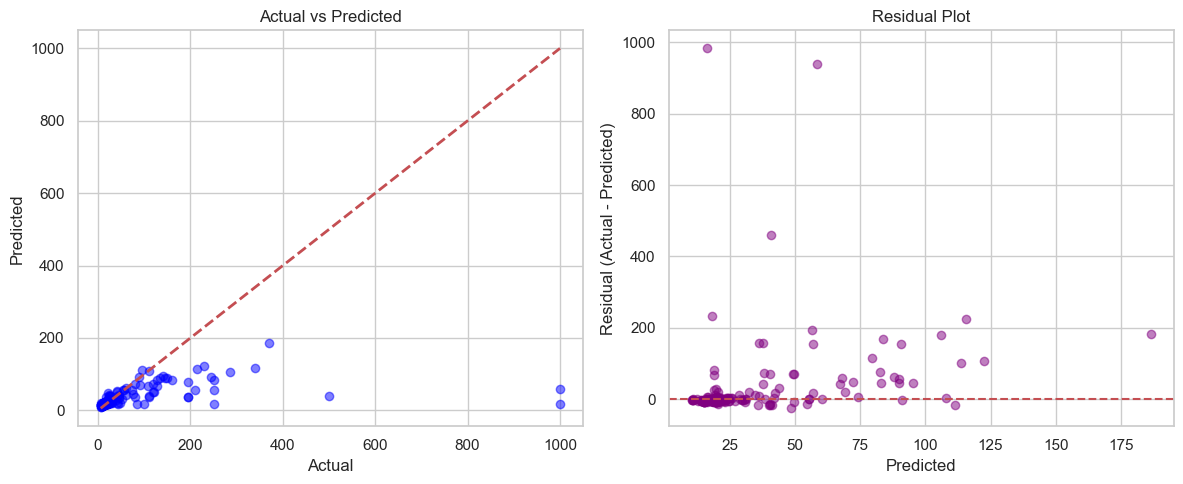

In [259]:
lrr = change_model(LinearRegression())

In [260]:
def diagnose(location:list):
    for i in range(len(location)):
        display(X_test.iloc[[location[i]]])

#### B.2 Random Forest Regressor

R^2     : 0.229
MAE     : 20.57
RMSE    : 95.87
MAPE    : 0.246
SMAPE   : 23.792


,item_id,title,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
838,v1|298576738093|0,Mushoku Tensei: Jobless Reincarnation (Light N...,1.0,1000.00,13.043417,9.869566e+02,9.869566e+02,9.869566e+01
1401,v1|388779634089|0,BGS9.6 Rascal Does Not Dream of Bunny Girl Sen...,1.0,999.00,47.200901,9.517991e+02,9.517991e+02,9.527519e+01
263,v1|168599137130|0,Classroom of the Elite Light Novel English Vol...,11.0,500.00,130.453570,3.695464e+02,3.695464e+02,7.390929e+01
874,v1|307070837046|0,Classroom Of The Elite Year 2 Volume 1 2 3 4 4...,1.0,249.99,12.434819,2.375552e+02,2.375552e+02,9.502587e+01
1038,v1|356411358026|0,Japanese Language Novel Bofuri: I Don't Want t...,18.0,285.00,119.504367,1.654956e+02,1.654956e+02,5.806864e+01
...,...,...,...,...,...,...,...,...
1155,v1|364057991156|0,"Bofuri: I Don't Want to Get Hurt, So I'll Max ...",1.0,8.76,8.734380,2.562013e-02,2.562013e-02,2.924672e-01
1773,v1|800405188256|0,"86--Eighty-Six, Vol. 4 (Light Novel): Under Pr...",1.0,16.34,16.326546,1.345405e-02,1.345405e-02,8.233811e-02
1267,v1|366540397064|0,Ascendance of a Bookworm: Part 5 Volume 11 (Li...,1.0,16.33,16.341979,-1.197885e-02,1.197885e-02,7.335487e-02
1427,v1|389609100557|0,Ascendance of a Bookworm (Light Novel) Ser.: A...,1.0,13.35,13.354916,-4.915706e-03,4.915706e-03,3.682177e-02


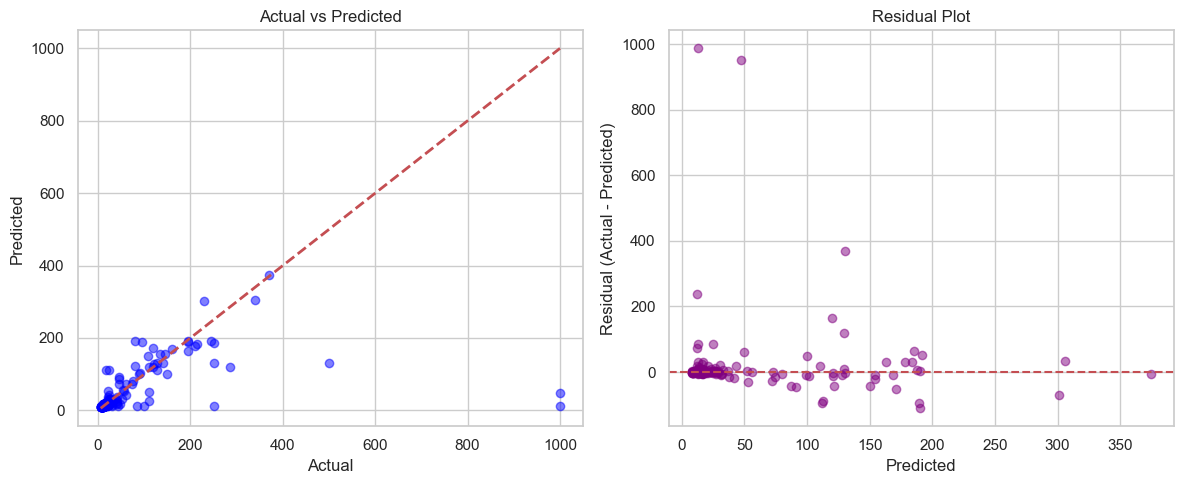

In [261]:
rfr = change_model(RandomForestRegressor(random_state = 42))

#### B.3 XGBoost

R^2     : 0.285
MAE     : 19.91
RMSE    : 92.35
MAPE    : 0.227
SMAPE   : 23.399


,item_id,title,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
838,v1|298576738093|0,Mushoku Tensei: Jobless Reincarnation (Light N...,1.0,1000.00,13.915717,986.084283,986.084283,98.608428
1401,v1|388779634089|0,BGS9.6 Rascal Does Not Dream of Bunny Girl Sen...,1.0,999.00,135.697418,863.302582,863.302582,86.416675
263,v1|168599137130|0,Classroom of the Elite Light Novel English Vol...,11.0,500.00,112.581604,387.418396,387.418396,77.483679
874,v1|307070837046|0,Classroom Of The Elite Year 2 Volume 1 2 3 4 4...,1.0,249.99,12.715374,237.274626,237.274626,94.913647
1038,v1|356411358026|0,Japanese Language Novel Bofuri: I Don't Want t...,18.0,285.00,144.395737,140.604263,140.604263,49.334829
...,...,...,...,...,...,...,...,...
1375,v1|387593975494|0,"Spy Classroom, Vol. 4 (light novel): Thea i......",1.0,8.15,8.165894,-0.015894,0.015894,0.195013
535,v1|227410375947|0,"Re:ZERO -Starting Life in Another World-, Vol....",1.0,13.75,13.763582,-0.013582,0.013582,0.098780
1419,v1|389609093174|0,Ascendance of a Bookworm (Light Novel) Ser.: A...,1.0,13.35,13.350003,-0.000003,0.000003,0.000024
1427,v1|389609100557|0,Ascendance of a Bookworm (Light Novel) Ser.: A...,1.0,13.35,13.350003,-0.000003,0.000003,0.000024


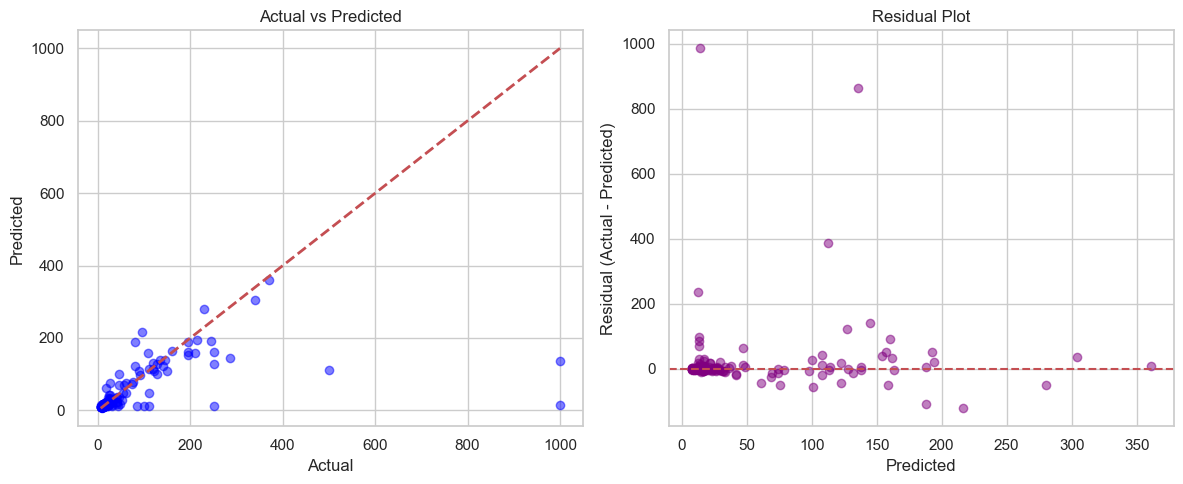

In [266]:
XGBr = change_model(XGBRegressor(random_state=42, tree_method = 'hist', objective='reg:absoluteerror'))